In [1]:
# Load data

In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
%config InlineBackend.figure_format = 'retina'


  # File paths
DATA_DIR = "../data/hnsc_tcga"
files = {
        'mutations': os.path.join(DATA_DIR, "data_mutations.txt"),
        'patient': os.path.join(DATA_DIR, "data_clinical_patient.txt"),
        'sample': os.path.join(DATA_DIR, "data_clinical_sample.txt")
}

# Load all files with pandas defaults
mutations = pd.read_csv(files['mutations'], sep='\t', low_memory=False)
patient_data = pd.read_csv(files['patient'], sep='\t', comment='#', low_memory=False)
sample_data = pd.read_csv(files['sample'], sep='\t', comment='#', low_memory=False)

# Print info
for name, df in [('MUTATIONS', mutations), ('PATIENT', patient_data),('SAMPLE', sample_data)]:
    print(f"\n=== {name} ===")
    print(f"Shape: {df.shape}")
    print("Columns:", list(df.columns[:8]), "...")
    print(df.head(2))


# HPV status investigation
for col in ['HPV_STATUS_P16', 'HPV_STATUS_ISH']:
    if col in patient_data.columns:
        print(f"\n=== {col} ===")
        print(f"Non-null: {patient_data[col].notna().sum()} / {len(patient_data)}")
        print(patient_data[col].value_counts(dropna=False))


=== MUTATIONS ===
Shape: (120402, 97)
Columns: ['Hugo_Symbol', 'Entrez_Gene_Id', 'Center', 'NCBI_Build', 'Chromosome', 'Start_Position', 'End_Position', 'Strand'] ...
  Hugo_Symbol  Entrez_Gene_Id         Center NCBI_Build Chromosome  \
0     CCDC181         57821.0  broad.mit.edu     GRCh37          1   
1      NBPF10     100132406.0  broad.mit.edu     GRCh37          1   

   Start_Position  End_Position Strand         Consequence  \
0       169390813     169390813      +    missense_variant   
1       145302714     145302714      +  synonymous_variant   

  Variant_Classification  ... Transcript_Strand  \
0      Missense_Mutation  ...                 -   
1                 Silent  ...                 +   

  FamilialCancerDatabase_Syndromes CCLE_ONCOMAP_overlapping_mutations  \
0                              NaN                                NaN   
1                              NaN                                NaN   

  GO_Cellular_Component UniProt_Natural_Variations Annotatio

In [3]:
#1 What mutation type exist and how are they distributed?

In [5]:
print(f"Total mutations: {len(mutations):,}")

Total mutations: 120,402



Top 10 mutation types:
Variant_Classification
Missense_Mutation    71910
Silent               28196
Nonsense_Mutation     5606
RNA                   3334
Frame_Shift_Del       2760
Intron                2268
Splice_Site           1901
Frame_Shift_Ins       1399
In_Frame_Del           984
Splice_Region          823
Name: count, dtype: int64

Total unique types: 17
Missense %: 59.7%
Silent %: 23.4%


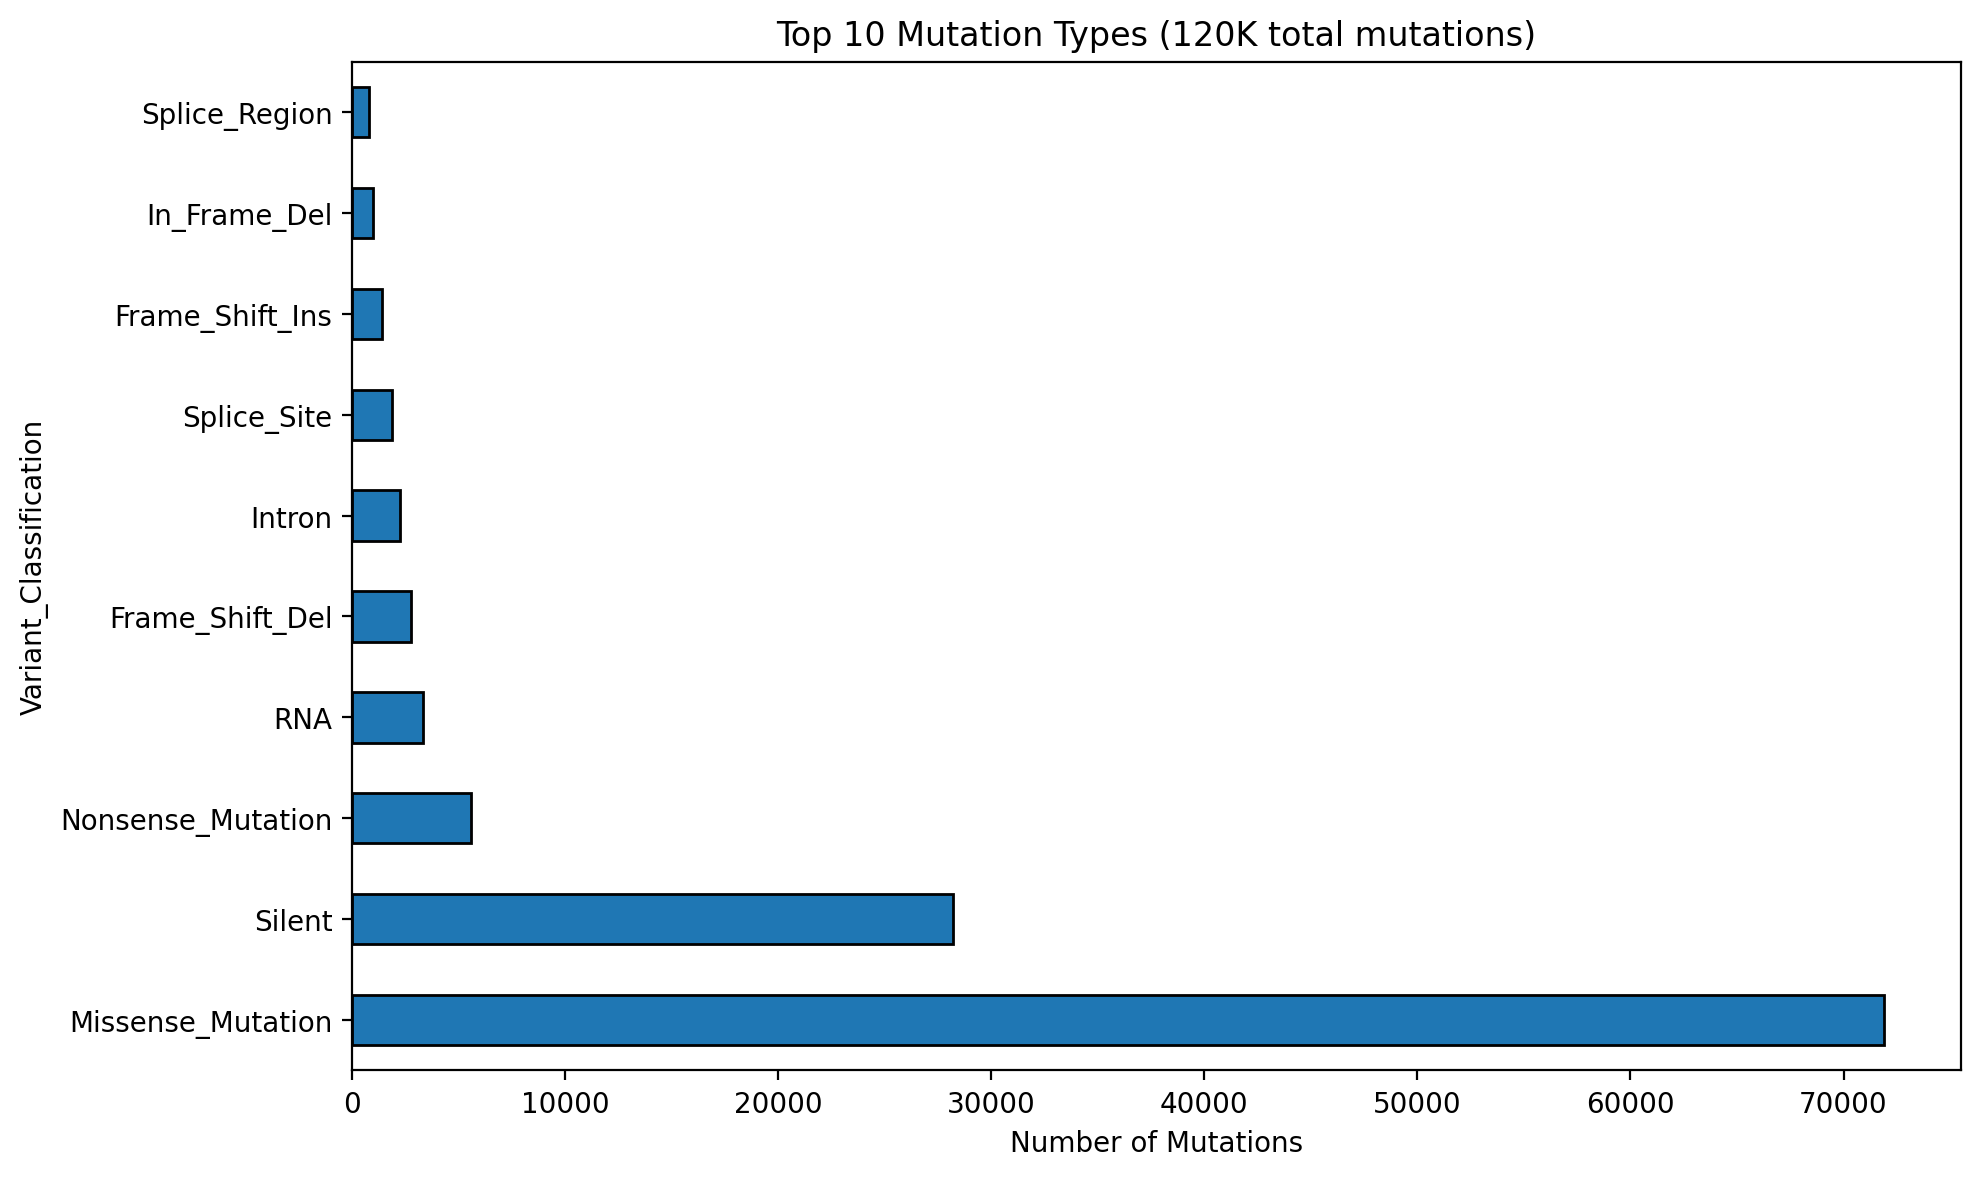

In [6]:
mut_types = mutations['Variant_Classification'].value_counts()    #Counts each unique value from the column
print(f"\nTop 10 mutation types:")
print(mut_types.head(10))
print(f"\nTotal unique types: {len(mut_types)}")
print(f"Missense %: {mut_types.get('Missense_Mutation', 0)/len(mutations)*100:.1f}%")
print(f"Silent %: {mut_types.get('Silent', 0)/len(mutations)*100:.1f}%")

# Plot
plt.figure(figsize=(10, 6))      # Make empty canvas (10" wide, 6" tall)
mut_types.head(10).plot(kind='barh', edgecolor='black')     # Bar chart (horizontal)
plt.title('Top 10 Mutation Types (120K total mutations)')
plt.xlabel('Number of Mutations')
plt.tight_layout()       # Fit nicely
plt.show()

In [7]:
#2 How many mutations per sample? (Find hypermutators)

Distribution stats:
count     512.000000
mean      235.160156
std       301.355889
min        11.000000
25%       106.750000
50%       160.500000
75%       259.250000
max      4410.000000
Name: count, dtype: float64

Median mutations/sample: 160
Max mutations/sample: 4410


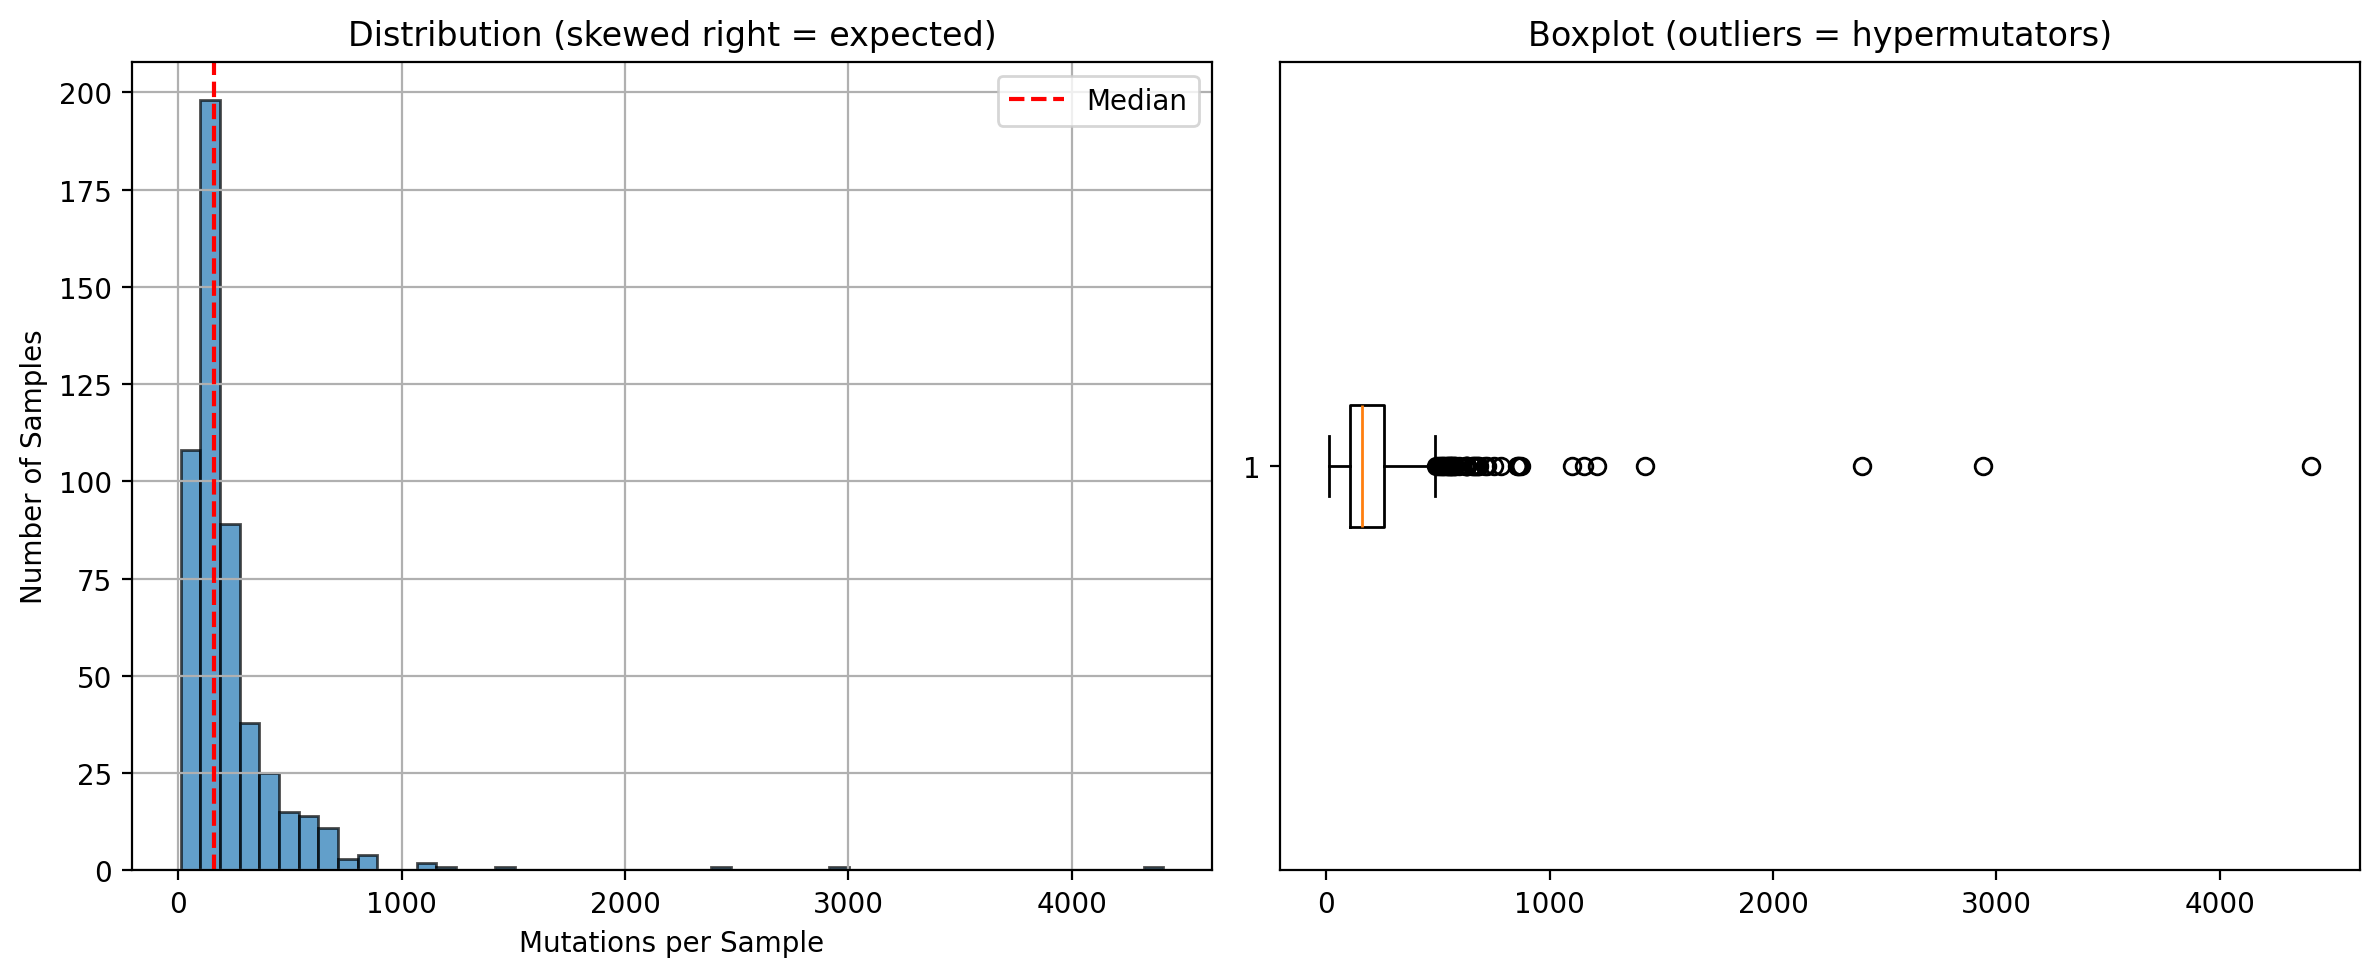


Hypermutators (IQR method): 46 samples
Top 5 most mutated: {'TCGA-F7-A624-01': 4410, 'TCGA-CV-7568-01': 2942, 'TCGA-D6-6516-01': 2399, 'TCGA-CV-6961-01': 1429, 'TCGA-CV-7245-01': 1213}
3SD threshold: > 1139 mutations
Hypermutators (3SD): 6 samples (1.2%)

IQR vs 3SD comparison:
IQR: 46 samples (9.0%)
3SD: 6 samples (1.2%)


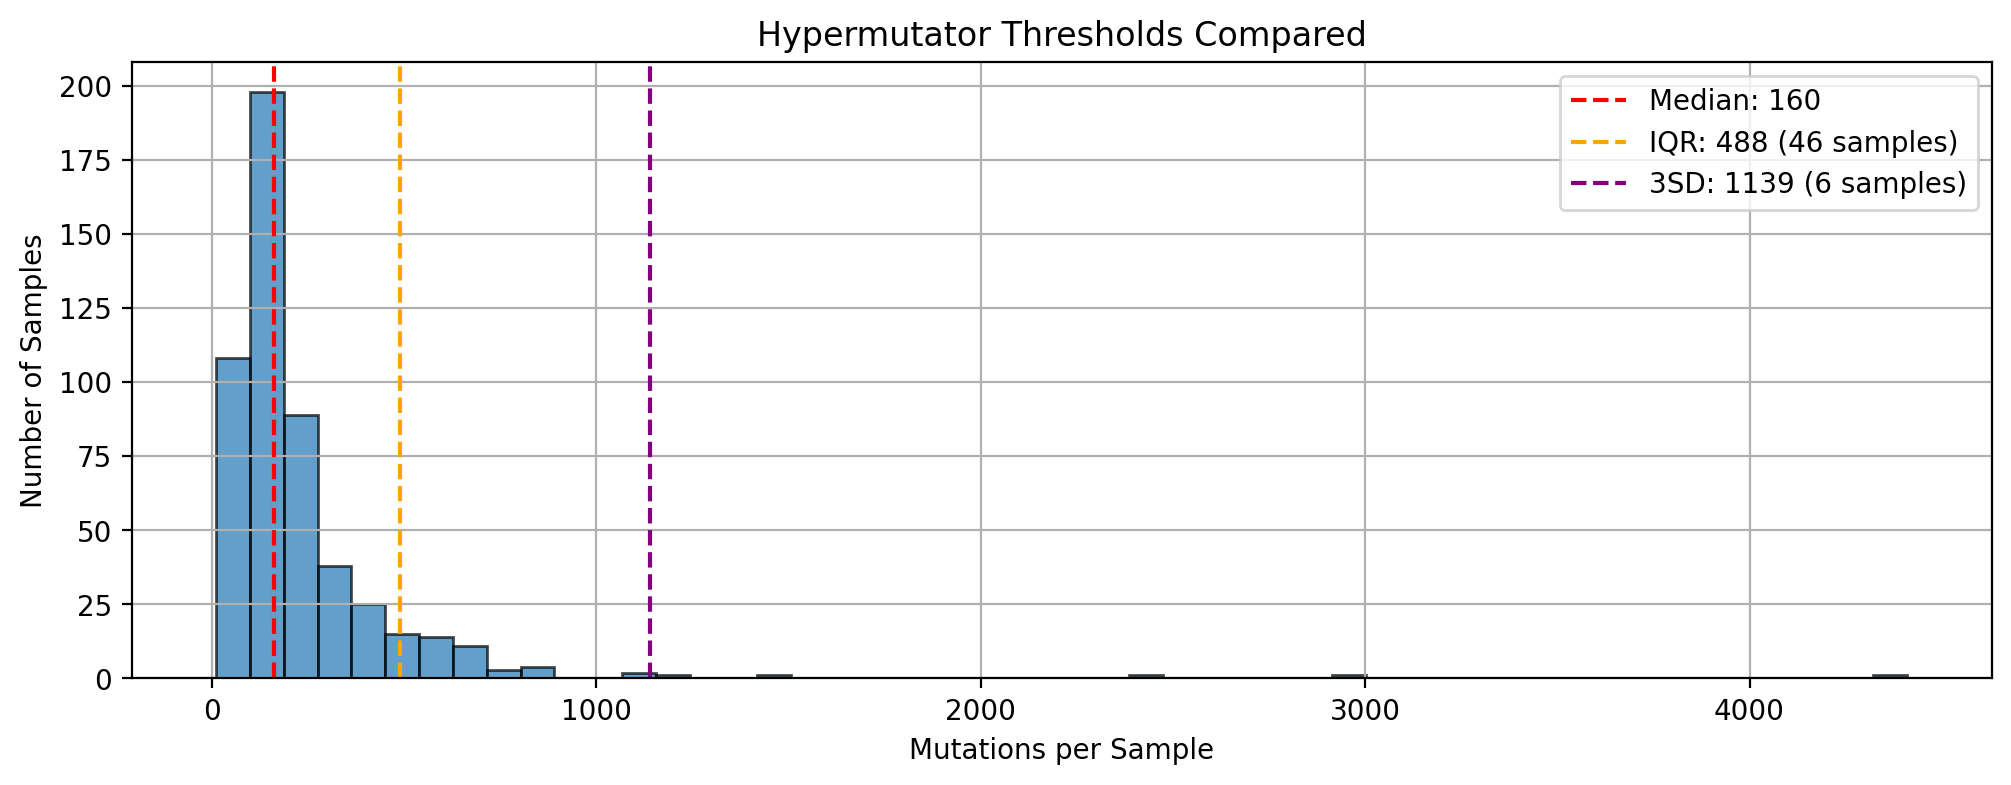


Top 5 hypermutators (3SD method):
Tumor_Sample_Barcode
TCGA-F7-A624-01    4410
TCGA-CV-7568-01    2942
TCGA-D6-6516-01    2399
TCGA-CV-6961-01    1429
TCGA-CV-7245-01    1213
Name: count, dtype: int64


In [8]:
# Count mutations by sample
sample_mut_counts = mutations['Tumor_Sample_Barcode'].value_counts()
print("Distribution stats:")
print(sample_mut_counts.describe())

print(f"\nMedian mutations/sample: {sample_mut_counts.median():.0f}")
print(f"Max mutations/sample: {sample_mut_counts.max()}")


# Plot histogram
plt.figure(figsize=(12, 5))

plt.subplot(1,2,1)
sample_mut_counts.hist(bins=50, edgecolor='black', alpha=0.7)
plt.axvline(sample_mut_counts.median(), color='red', linestyle='--', label='Median')
plt.xlabel('Mutations per Sample')
plt.ylabel('Number of Samples')
plt.title('Distribution (skewed right = expected)')
plt.legend()


plt.subplot(1,2,2)
plt.boxplot(sample_mut_counts, vert=False)
plt.title('Boxplot (outliers = hypermutators)')


plt.tight_layout()
plt.show()


# Flag hypermutators
median = sample_mut_counts.median()
iqr = sample_mut_counts.quantile(0.75) - sample_mut_counts.quantile(0.25)
upper_limit = sample_mut_counts.quantile(0.75) + 1.5 * iqr
hypermutators = sample_mut_counts[sample_mut_counts > upper_limit]


print(f"\nHypermutators (IQR method): {len(hypermutators)} samples")
print("Top 5 most mutated:", hypermutators.head().to_dict())


# 3SD method
mean_sd = sample_mut_counts.mean() + 3 * sample_mut_counts.std()
hyper_3sd = sample_mut_counts[sample_mut_counts > mean_sd]
print(f"3SD threshold: > {mean_sd:.0f} mutations")
print(f"Hypermutators (3SD): {len(hyper_3sd)} samples ({len(hyper_3sd)/512*100:.1f}%)")

print(f"\nIQR vs 3SD comparison:")
print(f"IQR: 46 samples (9.0%)")
print(f"3SD: {len(hyper_3sd)} samples ({len(hyper_3sd)/512*100:.1f}%)")


# Visual: overlay BOTH threshold on histogram
plt.figure(figsize=(12, 4))
sample_mut_counts.hist(bins=50, edgecolor='black', alpha=0.7)
plt.axvline(sample_mut_counts.median(), color='red', linestyle='--', label=f'Median: {sample_mut_counts.median():.0f}')
plt.axvline(upper_limit, color='orange', linestyle='--', label=f'IQR: {upper_limit:.0f} ({len(hypermutators)} samples)')
plt.axvline(mean_sd, color='purple', linestyle='--', label=f'3SD: {mean_sd:.0f} ({len(hyper_3sd)} samples)')
plt.xlabel('Mutations per Sample')
plt.ylabel('Number of Samples')
plt.title('Hypermutator Thresholds Compared')
plt.legend()
plt.show()

print("\nTop 5 hypermutators (3SD method):")
print(hyper_3sd.head())

In [9]:
#3 Top Mutated genes (Raw Frequency)

=== TOP 20 GENES (RAW FREQUENCY) ===
Analyzing 120,402 mutations across 512 samples

Top 20 genes (# samples mutated):
Hugo_Symbol
TP53       366
TTN        257
FAT1       124
MUC16      122
CSMD3      116
FRG1B      115
CDKN2A     113
LRP1B      106
SYNE1      104
NOTCH1      99
PIK3CA      95
PCLO        95
BAGE2       91
FLG         90
KMT2D       85
DNAH5       85
USH2A       81
RYR2        74
DST         69
PKHD1L1     67
Name: Tumor_Sample_Barcode, dtype: int64

TP53 frequency: 366 / 512 = 71.5%

Top 20 as % of samples:
Hugo_Symbol
TP53       71.484375
TTN        50.195312
FAT1       24.218750
MUC16      23.828125
CSMD3      22.656250
FRG1B      22.460938
CDKN2A     22.070312
LRP1B      20.703125
SYNE1      20.312500
NOTCH1     19.335938
PIK3CA     18.554688
PCLO       18.554688
BAGE2      17.773438
FLG        17.578125
KMT2D      16.601562
DNAH5      16.601562
USH2A      15.820312
RYR2       14.453125
DST        13.476562
PKHD1L1    13.085938
Name: Tumor_Sample_Barcode, dtype: f

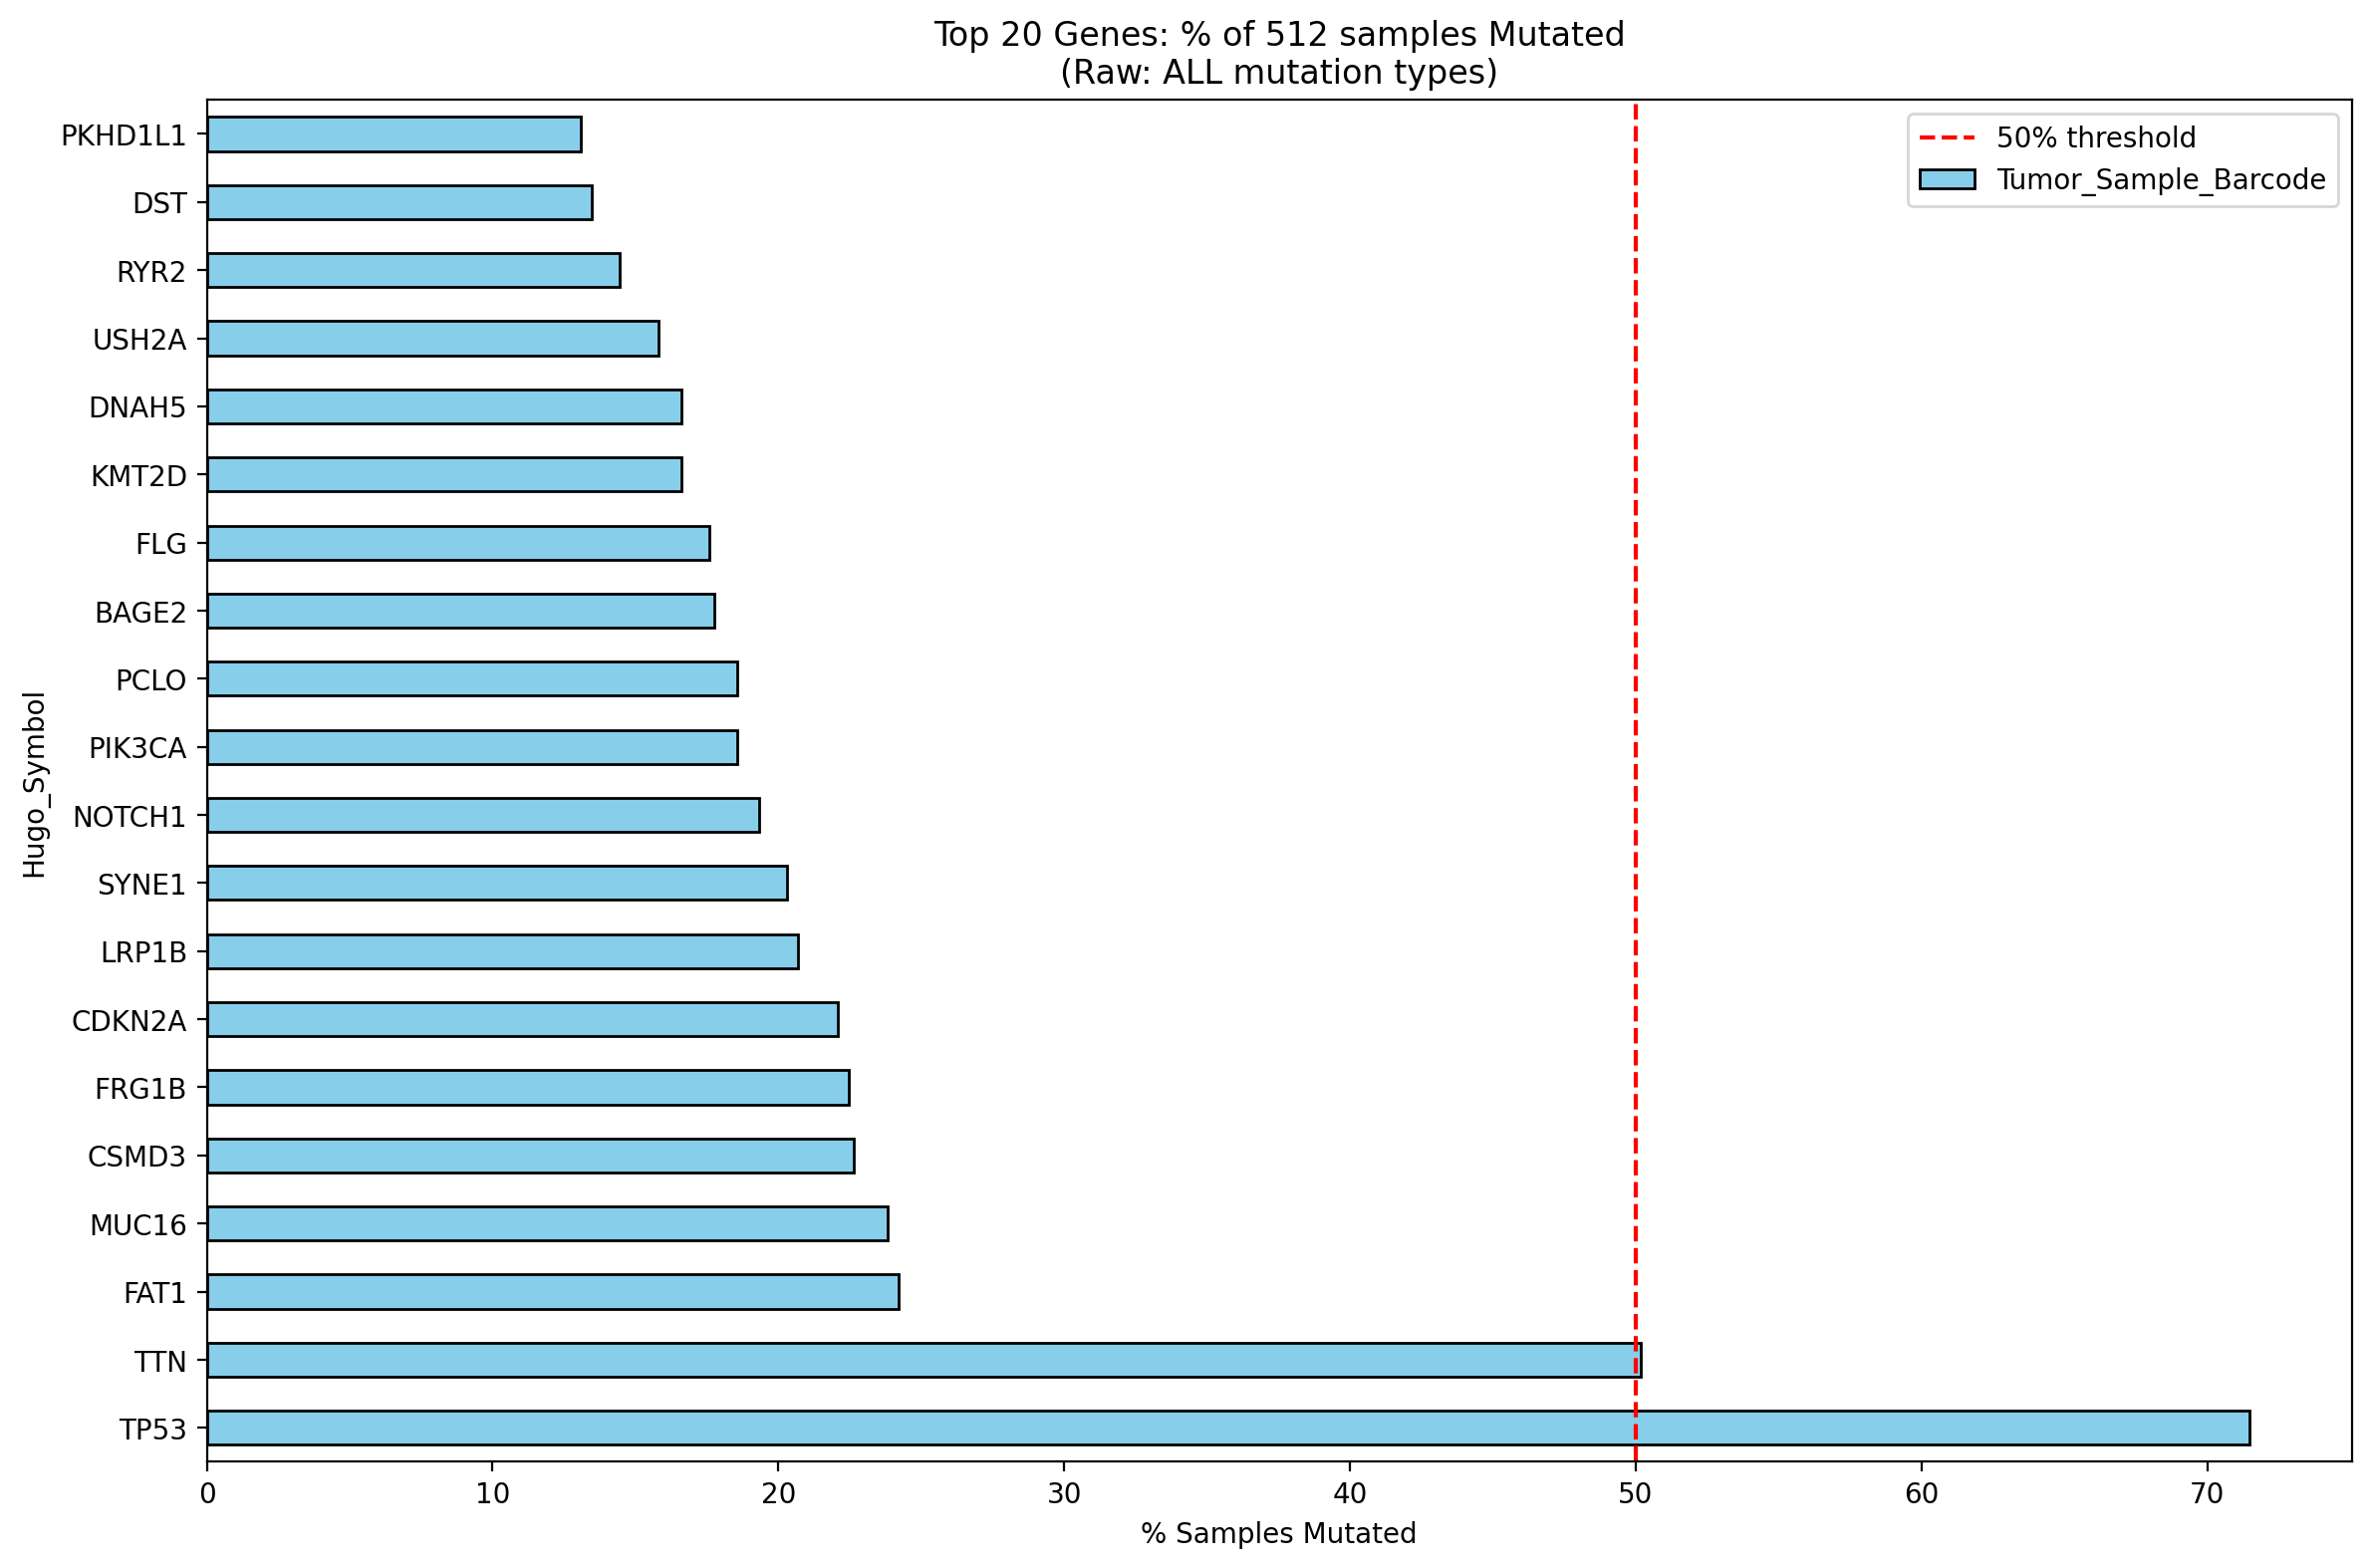

In [10]:
# Top genes by UNIQUE samples mutated (ALL mutation types)
print("=== TOP 20 GENES (RAW FREQUENCY) ===")
print(f"Analyzing {len(mutations):,} mutations across {len(sample_mut_counts)} samples")


# UNIQUE samples per gene
gene_sample_counts = (
    mutations.groupby('Hugo_Symbol')['Tumor_Sample_Barcode']
    .nunique()   # Count DISTINCT samples per gene
    .sort_values(ascending=False)
)

print("\nTop 20 genes (# samples mutated):")
top20 = gene_sample_counts.head(20)
print(top20)
print(f"\nTP53 frequency: {top20.get('TP53', 0)} / 512 = {top20.get('TP53', 0)/512*100:.1f}%")


# Percentage view
top20_pct = top20 / 512 * 100
print("\nTop 20 as % of samples:")
print(top20_pct.head(20))


# Plot
plt.figure(figsize=(12, 8))
top20_pct.head(20).plot(kind='barh', edgecolor='black', color='skyblue')
plt.title('Top 20 Genes: % of 512 samples Mutated\n(Raw: ALL mutation types)')
plt.xlabel('% Samples Mutated')
plt.axvline(x=50, color='red', linestyle='--', label='50% threshold')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
#4 Mutation Patterns (Driver vs Passenger)

=== Top 5 GENES * MUTATION PATTERNS ===
Mutation type breakdown (% within each gene):
Variant_Classification  Frame_Shift_Del  Frame_Shift_Ins  In_Frame_Del  \
Hugo_Symbol                                                              
TP53                               10.6              4.2           1.8   
TTN                                 1.5              0.5           0.2   
FAT1                               11.1             13.3           1.1   
MUC16                               1.9              1.4           0.0   
CSMD3                               2.1              1.0           0.0   

Variant_Classification  In_Frame_Ins  Intron  Missense_Mutation  \
Hugo_Symbol                                                       
TP53                             0.4     0.0               55.2   
TTN                              0.0     7.3               65.5   
FAT1                             0.0     0.0               18.9   
MUC16                            0.0     0.0               6

<Figure size 1400x600 with 0 Axes>

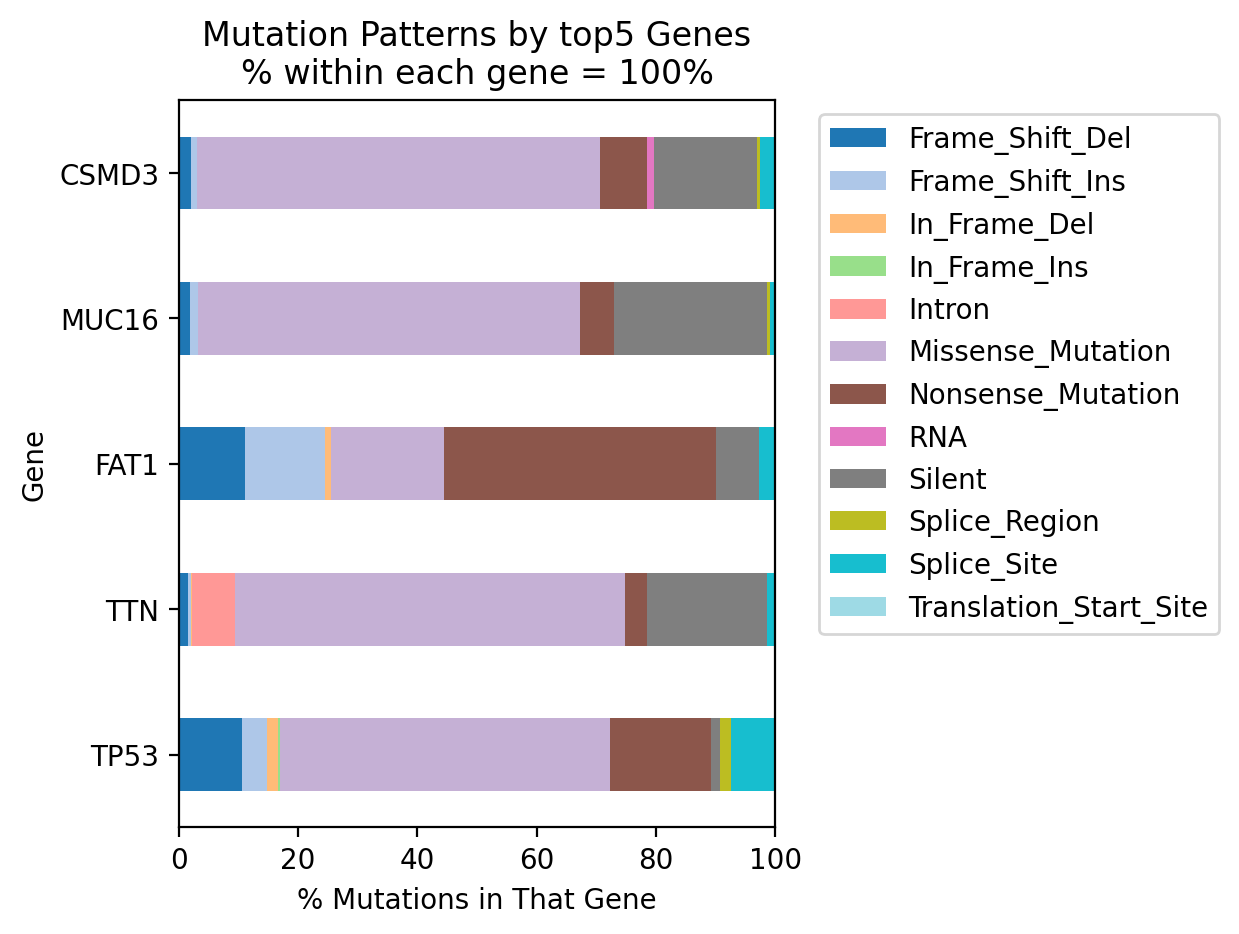

In [12]:
# Mutation pattern in top 5 genes (crosstab)
print("=== Top 5 GENES * MUTATION PATTERNS ===")


# Top 5 mutated genes
top5 = ['TP53', 'TTN', 'FAT1', 'MUC16', 'CSMD3']
subset = mutations[mutations['Hugo_Symbol'].isin(top5)]


# Crosstab: % of EACH mutation type WITHIN each gene
crosstab = pd.crosstab(subset['Hugo_Symbol'], subset['Variant_Classification'], 
                      normalize='index') * 100

print("Mutation type breakdown (% within each gene):")
print(crosstab.round(1).loc[top5])   # Clean order


# Plot
plt.figure(figsize=(14, 6))
crosstab.loc[top5].plot(kind='barh', stacked=True, cmap='tab20')
plt.title('Mutation Patterns by top5 Genes\n% within each gene = 100%')
plt.xlabel('% Mutations in That Gene')
plt.ylabel('Gene')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [13]:
#5 Clinical data exploration

=== CLINICAL DATA EXPLORATION ===
=== 1. TUMOR SITES ===
PRIMARY_SITE_PATIENT
Oral Tongue       133
Larynx            117
Oral Cavity        73
Floor of mouth     63
Tonsil             45
Base of tongue     27
Buccal Mucosa      23
Alveolar Ridge     18
Hypopharynx        10
Oropharynx          9
Hard Palate         7
Lip                 3
Name: count, dtype: int64

=== 2. AGE DISTRIBUTION ===
count    527.000000
mean      60.912713
std       11.926580
min       19.000000
25%       53.000000
50%       61.000000
75%       69.000000
max       90.000000
Name: AGE, dtype: float64

Missing age: 1 / 528


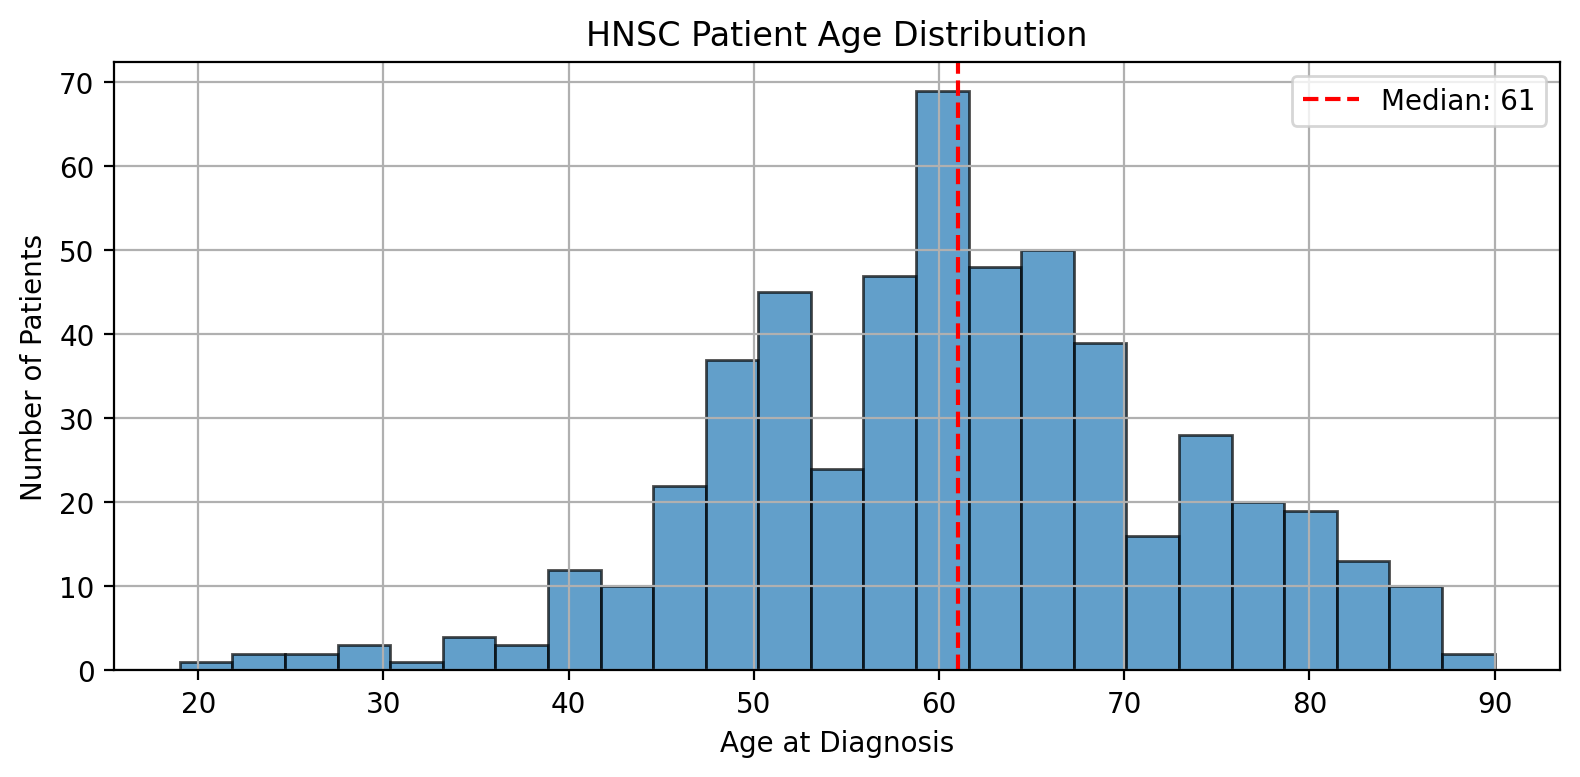


=== 3. STAGE DISTRIBUTION ==
AJCC_PATHOLOGIC_TUMOR_STAGE
Stage IVA        257
Stage III         82
Stage II          74
Stage I           27
Stage IVB         12
[Discrepancy]      4
Stage IVC          1
Name: count, dtype: int64

=== 4. SURVIVAL ===
Overall Survival (months):
count    526.000000
mean      30.042281
std       28.472089
min        0.070000
25%       12.427500
50%       21.175000
75%       38.672500
max      210.810000
Name: OS_MONTHS, dtype: float64

Vital status:
OS_STATUS
0:LIVING      304
1:DECEASED    224
Name: count, dtype: int64

=== 5. HPV STATUS (p16 only) ===
HPV_STATUS_P16
Negative    74
Positive    41
Name: count, dtype: int64
Evaluable: 115 / 528

=== 6. HPV+ BY TUMOR SITE ===
HPV_STATUS_P16        Negative  Positive  All
PRIMARY_SITE_PATIENT                         
Alveolar Ridge               2         0    2
Base of tongue               4        10   14
Buccal Mucosa                6         0    6
Floor of mouth               8         1    9
Hard Pala

In [21]:
print("=== CLINICAL DATA EXPLORATION ===")

# Clean NA values
na_vals = ['[Not Available]', '[Not Evaluated]', '[Not Applicable]']
patient_clean = patient_data.replace(na_vals, pd.NA)


# ---1. TUMOR SITES ---
print("=== 1. TUMOR SITES ===")
print(patient_clean['PRIMARY_SITE_PATIENT'].value_counts())

# ---2. AGE DISTRIBUTION---
print("\n=== 2. AGE DISTRIBUTION ===")
patient_clean['AGE'] = pd.to_numeric(patient_clean['AGE'], errors='coerce')

print(patient_clean['AGE'].describe())
print(f"\nMissing age: {patient_clean['AGE'].isna().sum()} / {len(patient_clean)}")

plt.figure(figsize=(8, 4))
patient_clean['AGE'].dropna().hist(bins=25, edgecolor='black', alpha=0.7)
plt.axvline(patient_clean['AGE'].median(), color='red', linestyle='--', label=f"Median: {patient_clean['AGE'].median():.0f}")
plt.xlabel('Age at Diagnosis')
plt.ylabel('Number of Patients')
plt.title('HNSC Patient Age Distribution')
plt.legend()
plt.tight_layout()
plt.show()


# ---3. STAGE DISTRIBUTION ---
print("\n=== 3. STAGE DISTRIBUTION ==")
print(patient_clean['AJCC_PATHOLOGIC_TUMOR_STAGE'].value_counts())


# ---4. SURVIVAL ---
print("\n=== 4. SURVIVAL ===")
patient_clean['OS_MONTHS'] = pd.to_numeric(patient_clean['OS_MONTHS'], errors='coerce')
patient_clean['DFS_MONTHS'] = pd.to_numeric(patient_clean['DFS_MONTHS'], errors='coerce')


print("Overall Survival (months):")
print(patient_clean['OS_MONTHS'].describe())
print(f"\nVital status:")
print(patient_clean['OS_STATUS'].value_counts())


# --- 5. HPV STATUS (P16 ONLY - our decision from Day 2) ---
print("\n=== 5. HPV STATUS (p16 only) ===")
print(patient_clean['HPV_STATUS_P16'].value_counts())
print(f"Evaluable: {patient_clean['HPV_STATUS_P16'].notna().sum()} / {len(patient_clean)}")


# --- 6. HPV BY ANATOMIC SITE (biological validation) ---
print("\n=== 6. HPV+ BY TUMOR SITE ===")
hpv_site = pd.crosstab(patient_clean['PRIMARY_SITE_PATIENT'], patient_clean['HPV_STATUS_P16'], margins=True)

print(hpv_site)

In [22]:
#6 Link mutations -> samples -> patients

print("=== DATA LINKING TEST ===")
print(f"Mutations: {len(mutations['Tumor_Sample_Barcode'].unique())} unique samples")
print(f"Samples: {len(sample_data['SAMPLE_ID'].unique())} total")
print(f"Patients: {len(patient_data['PATIENT_ID'].unique())} total")

# 1. SHOW RAW ID FORMATS (side-by-side)
print("\n1. RAW ID FORMATS (First 5 each):")
print("Mutations Tumor_Sample_Barcode:")
print(mutations['Tumor_Sample_Barcode'].head().tolist())
print("\nSample SAMPLE_ID:")
print(sample_data['SAMPLE_ID'].head().tolist())
print("\nSample PATIENT_ID:")
print(sample_data['PATIENT_ID'].head().tolist())
print("\nPatient PATIENT_ID:")
print(patient_data['PATIENT_ID'].head().tolist())


# 2. TEST MERGE (10 rows)
print("\n2. MERGE TEST (mutations → sample → patient):")
merge_test = (
    mutations[['Hugo_Symbol', 'Tumor_Sample_Barcode']].head(10)
    .merge(sample_data[['SAMPLE_ID', 'PATIENT_ID']], 
           left_on='Tumor_Sample_Barcode', right_on='SAMPLE_ID', how='left')
    .merge(patient_data[['PATIENT_ID', 'PRIMARY_SITE_PATIENT', 'OS_STATUS']], 
           on='PATIENT_ID', how='left', suffixes=('', '_patient'))
)
print(merge_test)
print(f"\nMerge success: {merge_test['PATIENT_ID'].notna().sum()}/10 rows = {merge_test['PATIENT_ID'].notna().mean()*100:.0f}%")

# 3. FULL COUNTS
print("\n3. FULL PIPELINE COUNTS:")
mut_samples = mutations['Tumor_Sample_Barcode'].nunique()
sample_match = sample_data['SAMPLE_ID'].isin(mutations['Tumor_Sample_Barcode']).sum()
print(f"Mutations cover {mut_samples} samples")
print(f"Matching SAMPLE_IDs found: {sample_match}/{len(sample_data['SAMPLE_ID'])} = {sample_match/len(sample_data['SAMPLE_ID'])*100:.1f}%")


# 4. HPV SAMPLE LINKING
hpv_patient_cols = [col for col in patient_data.columns if 'HPV_STATUS_P16' in col.upper()]
print(f"HPV columns found: {hpv_patient_cols}")

if hpv_patient_cols:
    # Extract HPV+ patients (fix: consistent variable name + NaN handling)
    hpv_mask = patient_data[hpv_patient_cols].astype(str).apply(
        lambda x: x.str.contains('Positive|pos', case=False, na=False).any(), axis=1
    )
    hpv_pos_patients = patient_data[hpv_mask]['PATIENT_ID'].unique()
    
    # Link to samples → mutations
    hpv_pos_samples = sample_data[sample_data['PATIENT_ID'].isin(hpv_pos_patients)]['SAMPLE_ID']
    hpv_mutations = mutations[mutations['Tumor_Sample_Barcode'].isin(hpv_pos_samples)]
    
    print(f"HPV+ patients: {len(hpv_pos_patients)}")
    print(f"HPV+ samples: {len(hpv_pos_samples)}")
    print(f"HPV+ mutations: {len(hpv_mutations):,}")
    print(f"HPV+ TP53 mutations: {hpv_mutations['Hugo_Symbol'].eq('TP53').sum()}")
    print("\nHPV+ sample example:", hpv_pos_samples.iloc[0] if len(hpv_pos_samples) > 0 else "None")
else:
    print("No HPV columns in patient_data (check sample_data instead)")

=== DATA LINKING TEST ===
Mutations: 512 unique samples
Samples: 530 total
Patients: 528 total

1. RAW ID FORMATS (First 5 each):
Mutations Tumor_Sample_Barcode:
['TCGA-CV-6935-01', 'TCGA-CV-6935-01', 'TCGA-CV-6935-01', 'TCGA-CV-6935-01', 'TCGA-CV-6935-01']

Sample SAMPLE_ID:
['TCGA-CN-6010-01', 'TCGA-CN-6011-01', 'TCGA-CN-6012-01', 'TCGA-CN-6013-01', 'TCGA-CN-6016-01']

Sample PATIENT_ID:
['TCGA-CN-6010', 'TCGA-CN-6011', 'TCGA-CN-6012', 'TCGA-CN-6013', 'TCGA-CN-6016']

Patient PATIENT_ID:
['TCGA-4P-AA8J', 'TCGA-BA-4074', 'TCGA-BA-4075', 'TCGA-BA-4076', 'TCGA-BA-4077']

2. MERGE TEST (mutations → sample → patient):
  Hugo_Symbol Tumor_Sample_Barcode        SAMPLE_ID    PATIENT_ID  \
0     CCDC181      TCGA-CV-6935-01  TCGA-CV-6935-01  TCGA-CV-6935   
1      NBPF10      TCGA-CV-6935-01  TCGA-CV-6935-01  TCGA-CV-6935   
2        ZIM3      TCGA-CV-6935-01  TCGA-CV-6935-01  TCGA-CV-6935   
3       FREM2      TCGA-CV-6935-01  TCGA-CV-6935-01  TCGA-CV-6935   
4        PCLO      TCGA-CV-6935-